In [103]:
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict
import astropy.units as u

import multiprocessing as mul

from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit
from pyLIMA.models import PSPL_model
from pyLIMA.models import USBL_model, pyLIMA_fancy_parameters
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

path = '../examples/data/'

In [104]:
event_1 = event.Event(ra=268.75425, dec=-29.047111111111114)
event_1.name = 'OB150966'

data_1 = np.loadtxt(path + 'OGLE_OB150966.dat')
telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt(path + 'MOA_OB150966.dat')
telescope_2 = telescopes.Telescope(name = 'MOA', 
                                   camera_filter = 'I+R',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_3 = np.loadtxt(path + 'SPITZER_OB150966.dat')
telescope_3 = telescopes.Telescope(name = 'SPITZER', 
                                   camera_filter = 'IRAC1',
                                   lightcurve = data_3.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

telescope_3.location = 'Space'
telescope_3.spacecraft_name = 'Spitzer'

data_4 = np.loadtxt(path + 'DANISH_OB150966.dat')
telescope_4 = telescopes.Telescope(name = 'DANISH', 
                                   camera_filter = 'Z+I',
                                   lightcurve = data_4.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_5 = np.loadtxt(path + 'LCO_CTIO_A_OB150966.dat')
telescope_5 = telescopes.Telescope(name = 'LCO_CTIO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_5.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_6 = np.loadtxt(path + 'LCO_CTIO_B_OB150966.dat')
telescope_6 = telescopes.Telescope(name = 'LCO_CTIO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_6.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_7 = np.loadtxt(path + 'LCO_CTIO_OB150966.dat')
telescope_7 = telescopes.Telescope(name = 'LCO_CTIO', 
                                   camera_filter = 'I',
                                   lightcurve = data_7.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_8 = np.loadtxt(path + 'LCO_SAAO_OB150966.dat')
telescope_8 = telescopes.Telescope(name = 'LCO_SAAO', 
                                   camera_filter = 'I',
                                   lightcurve = data_8.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_9 = np.loadtxt(path + 'LCO_SSO_A_OB150966.dat')
telescope_9 = telescopes.Telescope(name = 'LCO_SSO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_9.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_10 = np.loadtxt(path + 'LCO_SSO_B_OB150966.dat')
telescope_10 = telescopes.Telescope(name = 'LCO_SSO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_10.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_11 = np.loadtxt(path + 'LCO_SSO_OB150966.dat')
telescope_11 = telescopes.Telescope(name = 'LCO_SSO', 
                                   camera_filter = 'I',
                                   lightcurve = data_11.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

event_1.telescopes.append(telescope_1)
event_1.telescopes.append(telescope_2)
# event_1.telescopes.append(telescope_3)
event_1.telescopes.append(telescope_4)
event_1.telescopes.append(telescope_5)
event_1.telescopes.append(telescope_6)
event_1.telescopes.append(telescope_7)
event_1.telescopes.append(telescope_8)
# event_1.telescopes.append(telescope_9)
# event_1.telescopes.append(telescope_10)
# event_1.telescopes.append(telescope_11)

event_1.find_survey('OGLE')

event_1.check_event()


check_event  : Everything looks fine...


In [105]:
### Create a new EVENT object and give it a name.
event_2 = event.Event()
event_2.name = 'My event name'

### Load up the data.
data_1 = np.loadtxt(path + 'Survey_1.dat')
outliers_1 = [[80.055, 13.86, 0.01], [80.060, 13.76, 0.01], [80.065, 13.82, 0.01]]
data_1 = np.append(data_1, outliers_1, axis=0)

telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt(path + 'Followup_1.dat')
outliers_2 = [[80.055, 10.10, 0.01], [80.060, 10.00, 0.01], [80.065,  10.05, 0.01]]
data_2 = np.append(data_2, outliers_2, axis=0)
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

### Append these two telescope data sets to your EVENT object.
event_2.telescopes.append(telescope_1)
event_2.telescopes.append(telescope_2)
event_2.telescopes[0].ld_gamma = 0.5
event_2.telescopes[1].ld_gamma = 0.5

### Define the survey telescope that you want to use to align all other data sets to.
event_2.find_survey('OGLE')

### Run a quick sanity check on your input.
event_2.check_event()

check_event  : Everything looks fine...


check_event  : Everything looks fine...
[2458565.25, 0.6, 81.5, np.float64(10000.0), np.float64(1000.0)]
   time          mag         ...      err_flux         inv_err_flux   
    JD                       ...                                      
--------- ------------------ ... ----------------- -------------------
2458365.5 19.614590539191283 ... 5.096160207482804 0.19622617015290808
2458372.5 19.595969091504692 ... 5.161407944685054 0.19374558467709324
2458379.5 19.558959656645495 ... 5.234526922834518 0.19103923138454237
2458386.5 19.519065071317826 ... 5.316534359026418 0.18809245505997696
2458393.5 19.486236306612476 ... 5.408576125754211 0.18489154571353156
2458400.5  19.43929377350683 ... 5.511940071125387  0.1814243237582638
2458407.5 19.402175984803634 ... 5.628069669673201 0.17768081397223817
2458414.5  19.35033168002517 ... 5.758577628517752   0.173653993140212
2458421.5 19.293323489399192 ... 5.905258906515386  0.1693405853715712
      ...                ... ...           

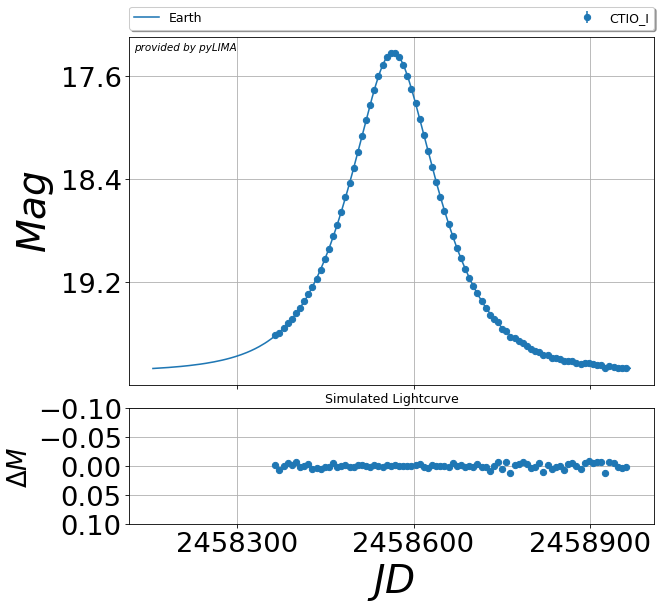

In [106]:
from pyLIMA.simulations import simulator

event_3 = event.Event(ra=270, dec=0)
event_3.name = 'My simulated event'

CTIO_I = simulator.simulate_a_telescope(name='CTIO_I', time_start=2458365.5, time_end=2458965.5, sampling=168, 
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)

event_3.telescopes.append(CTIO_I)
event_3.check_event()

pspl_sim = PSPL_model.PSPLmodel(event_3)
pspl_parameters = simulator.simulate_microlensing_model_parameters(pspl_sim)

### Set the parameters to some reasonable values.
pspl_parameters[0] = 2458565.25 # t0
pspl_parameters[1:3] = [0.60, 81.50] # u0, tE

### Set the source and blend fluxes of all telescopes to the same values for plotting purposes.
n_tel = len(event_3.telescopes)
pspl_parameters[-n_tel*2::2] = 10000. * np.ones(n_tel) # source fluxes
pspl_parameters[-n_tel*2+1::2] = 1000. * np.ones(n_tel) # blend fluxes
print(pspl_parameters)

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = pspl_sim.compute_pyLIMA_parameters(pspl_parameters)

### Inject everthing into the simulator to produce a light curve.
simulator.simulate_lightcurve(pspl_sim, pyLIMA_parameters_1)

### Edit datapoints to outlier
event_3.telescopes[0].lightcurve[20]['mag'] -= 0.5
print(event_3.telescopes[0].lightcurve)

pyLIMA_plots.plot_lightcurves(pspl_sim, pspl_parameters)
plt.title('Simulated Lightcurve')
plt.show()

In [107]:
# Select event
my_event = event_1

initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2457205.5, 1.0, 100.0, 10930.970566472577, 1169.4554524924188, 14754.541793735672, 2331.6033359688827, 80928.59568152676, 80928.59568152676, 4649.317493007159, 4649.317493007159, 54141.515025684675, 54141.515025684675, 78135.64550125551, 78135.64550125551, 1559.74644458226, 1559.74644458226]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2457205.2020610264)),
             ('u0', np.float64(0.010773735664599545)),
             ('tE', np.float64(61.615355458461195)),
             ('fsource_OGLE', np.float64(1207.5470368776455)),
             ('ftotal_OGLE', np.float64(1250.7244074491596)),
             ('fsource_MOA', np.float64(1201.129088570088)),
             ('ftotal_MOA', np.float64(2728.2908488341827)),
             ('fsource_DANISH', np.float64(1563.7114712968475)),
             ('ftotal_DANISH', np.float64(10091.367933651658)),
             ('fsource_LCO_CTIO_A', np.float64(87.2488827

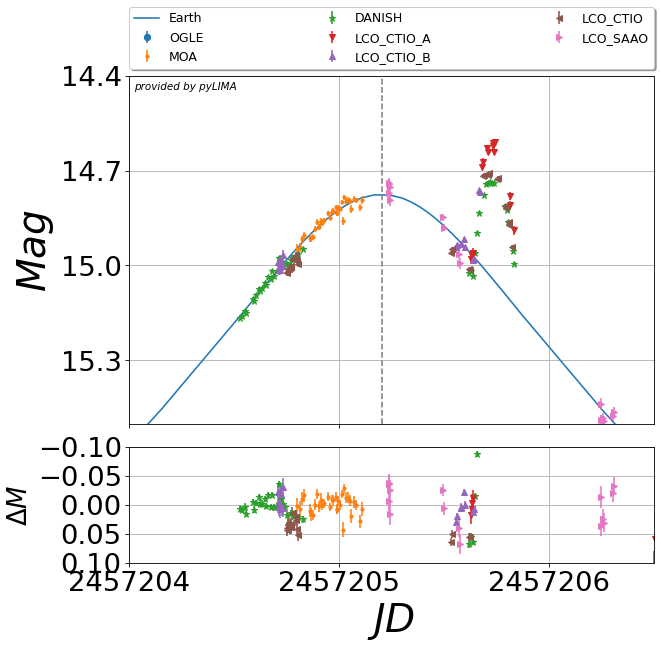

In [108]:
# PSPL model
pspl = PSPL_model.PSPLmodel(my_event)
# Robust fit
fit = TRF_fit.TRFfit(pspl, loss_function='soft_l1')
if my_event == event_1:
    fit.model_parameters_guess = [2457205.5, 1.0, 100.0]
fit.fit()
params =  OrderedDict(zip(fit.priors_parameters.keys(), fit.fit_results['best_model']))

# Plot
fig, _ = pyLIMA_plots.plot_lightcurves(pspl, fit.fit_results['best_model'])
### Set the window dimension.
if my_event == event_1:
    fig.axes[0].set_xlim(2457204.0, 2457206.5)
    fig.axes[0].set_ylim(15.50, 14.40)
if my_event == event_2:
    fig.axes[0].set_xlim(79.75, 80.25)
    fig.axes[0].set_ylim(14.50, 13.7)
# Line at t0
fig.axes[0].axvline(params['t0'], color='gray', linestyle='--')
plt.show()

In [109]:
import reldev_grid as rd

# assumptions
q = 0.001 
rs = 0.0005

# get parameters from pspl fit
# print(params)
t0 = params['t0']
u0 = params['u0']
te = params['tE']

# algorithm parameters
range = (t0 - 1, t0 + 1) # distance from t0 to compute reldev [in JD]

# Setup Meshgrid
x_min=-2.5, 
x_max=2.5, 
y_min=-2.5, 
y_max=2.5, 
resolution=100
x_range = np.linspace(x_min, x_max, resolution)
y_range = np.linspace(y_min, y_max, resolution)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_total = np.zeros_like(X_grid)

# running values
n_points = 0

# per telescope
for telescope in my_event.telescopes:
    name = telescope.name
    # telescope parameters from fit
    fs = params['fsource_' + name]
    fb = params['ftotal_' + name] - params['fsource_' + name] # unused

    # per datapoint
    for datapoint in telescope.lightcurve:
        # parameters from datapoint
        t = datapoint['time'].value # in [JD]
        ferr = datapoint['err_flux'].value # in [W/m^2]

        # check if datapoint inside relevant range
        if t > range[0] and t < range[1]:
            # setup a vectorized function to compute reldev at each point
            def vectorized_reldev_wrapper(X_arr, Y_arr):
                vectorized_func = np.vectorize(lambda x, y: rd.reldev(q, t, u0, te, t0, fs, fb, ferr, rs, x, y))
                return vectorized_func(X_arr, Y_arr)
            
            # run calculate reldev values on meshgrid
            print(f'Running Grid Analysis for {name} at t={t}.')
            Z = np.log10(vectorized_reldev_wrapper(X_grid, Y_grid))
            Z_total += Z
            n_points += 1

# Normalize Z_total
Z_total /= n_points

Running Grid Analysis for MOA at t=2457204.7999.
Running Grid Analysis for MOA at t=2457204.8131.
Running Grid Analysis for MOA at t=2457204.8237.
Running Grid Analysis for MOA at t=2457204.8329.
Running Grid Analysis for MOA at t=2457204.8597.
Running Grid Analysis for MOA at t=2457204.868.
Running Grid Analysis for MOA at t=2457204.8772.
Running Grid Analysis for MOA at t=2457204.8864.
Running Grid Analysis for MOA at t=2457204.8947.
Running Grid Analysis for MOA at t=2457204.9031.
Running Grid Analysis for MOA at t=2457204.9123.
Running Grid Analysis for MOA at t=2457204.9206.
Running Grid Analysis for MOA at t=2457204.9299.
Running Grid Analysis for MOA at t=2457204.9474.
Running Grid Analysis for MOA at t=2457204.9558.
Running Grid Analysis for MOA at t=2457204.965.
Running Grid Analysis for MOA at t=2457204.9733.
Running Grid Analysis for MOA at t=2457204.9862.
Running Grid Analysis for MOA at t=2457204.9908.
Running Grid Analysis for MOA at t=2457204.9918.
Running Grid Analysis 

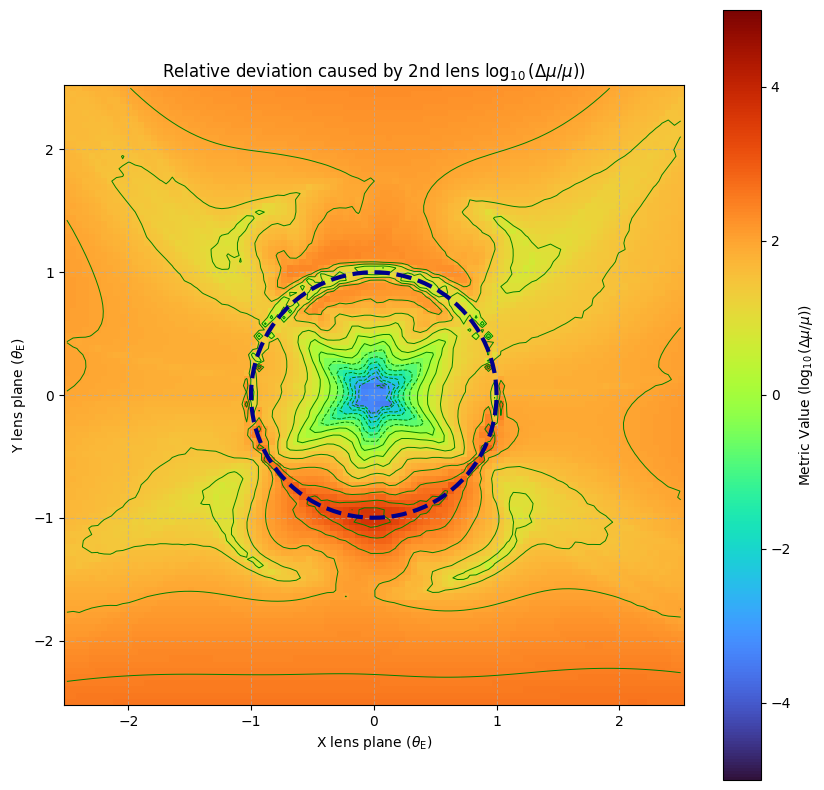

In [110]:
# Heatmap Plot
rd.plot_heatmap(X_grid, Y_grid, Z_total, 0, 0) 

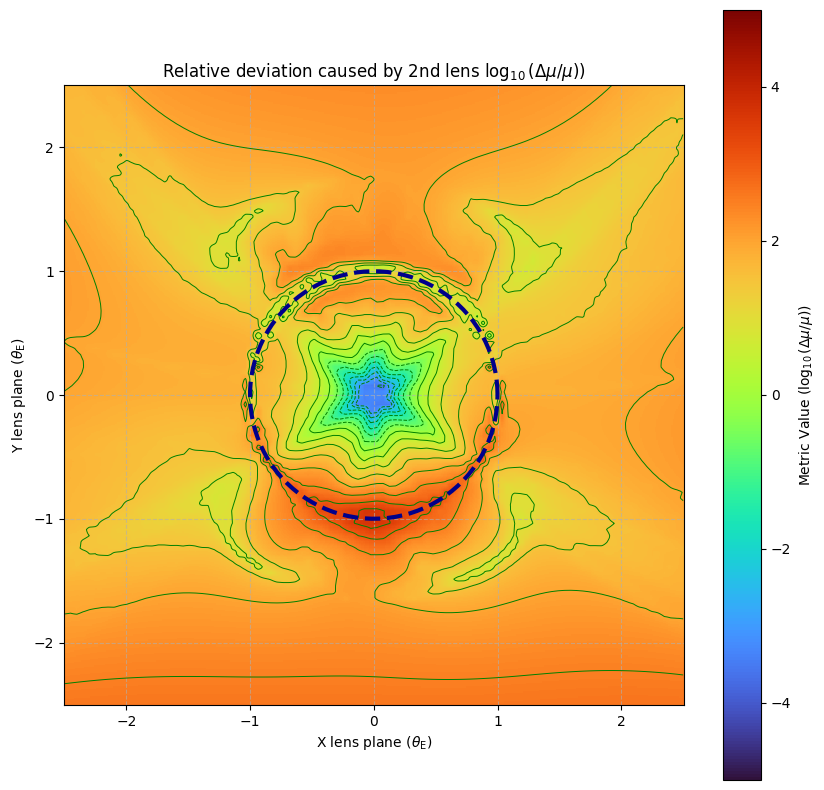

In [111]:
from scipy import interpolate

# Interpolate the grid 
resolution_interpol=5
x_fine = np.linspace(x_min, x_max, resolution * resolution_interpol)
y_fine = np.linspace(y_min, y_max, resolution * resolution_interpol)   
X_f, Y_f = np.meshgrid(x_fine, y_fine)
interp_func = interpolate.RegularGridInterpolator((x_range.ravel(), y_range.ravel()), Z_total.T, method="linear")

# Plotting the result
points = np.array([X_f.ravel(), Y_f.ravel()]).T
Z_fine = interp_func(points).reshape(X_f.shape)
rd.plot_heatmap(X_f, Y_f, Z_fine, x_fine, y_fine) 
